1.1. Wall detection (2D LIDAR + Hought transform)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

Generating Data

In [ ]:

def get_room_vertices():
    vertices = np.array([
        [ 0.0,  0.0],
        [ 0.0, 10.0],
        [ 6.0, 10.0],
        [ 6.0,  7.0],
        [11.0,  7.0],
        [11.0,  3.0],
        [14.0,  3.0],
        [14.0,  0.0],
        [ 9.0,  0.0],
        [ 9.0,  2.5],
        [ 5.0,  2.5],
        [ 5.0,  0.0],
        [ 0.0,  0.0],
    ], dtype=float)
    return vertices



def generate_lidar_points(vertices, points_per_segment=80, noise_std=0.04):
    points = []

    for i in range(len(vertices)-1):
        p1 = vertices[i]
        p2 = vertices[i+1]

        t = np.linspace(0, 1, points_per_segment, endpoint=False)
        segment_points = (1-t)[:,None] * p1 + t[:,None] * p2

        direction = p2 - p1
        perp = np.array([-direction[1], direction[0]])
        if np.linalg.norm(perp) > 1e-9:
            perp /= np.linalg.norm(perp)

        # случайный шум вдоль нормали
        noise_magnitude = np.random.normal(0, noise_std, size=len(t))
        segment_points += noise_magnitude[:,None] * perp

        points.append(segment_points)

    points = np.vstack(points)
    return points


Сгенерировано точек: 1440


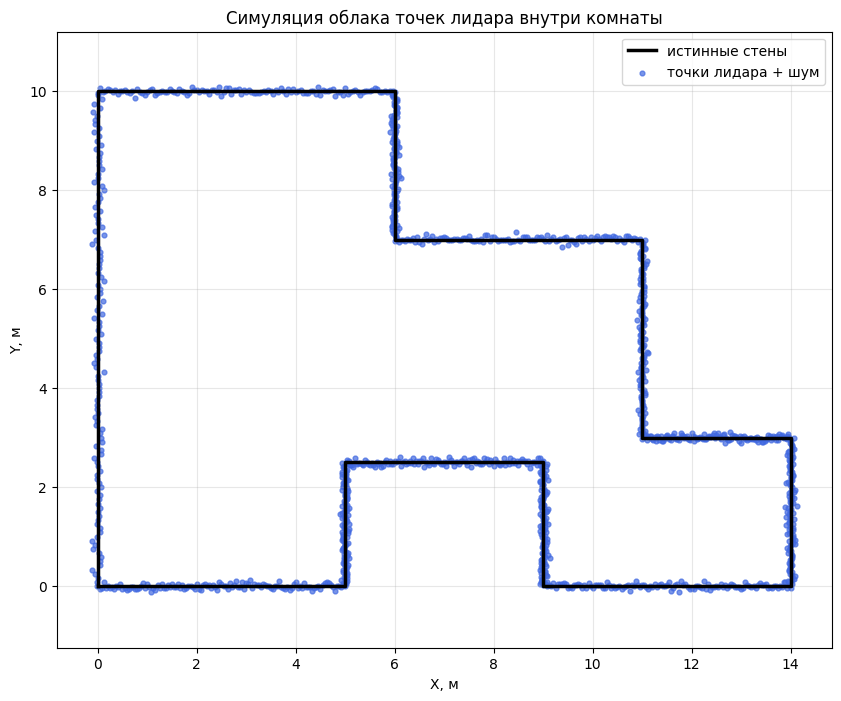

In [24]:

def plot_room_and_points(vertices, points):
    plt.figure(figsize=(10, 8))

    # оригинальный контур (жирная линия)
    plt.plot(vertices[:,0], vertices[:,1], 'k-', lw=2.5, label='истинные стены')
    plt.plot([vertices[-1,0], vertices[0,0]],
             [vertices[-1,1], vertices[0,1]], 'k-', lw=2.5)

    # сгенерированные точки лидара
    plt.scatter(points[:,0], points[:,1], s=12, c='royalblue', alpha=0.7,
                label='точки лидара + шум')

    plt.axis('equal')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title("Симуляция облака точек лидара внутри комнаты")
    plt.xlabel("X, м")
    plt.ylabel("Y, м")
    plt.show()


if __name__ == "__main__":
    # форма комнаты
    vertices = get_room_vertices()

    # генерация точек с шумом
    lidar_points = generate_lidar_points(
        vertices,
        points_per_segment=120,     # чем больше — тем плотнее
        noise_std=0.045             # 4–5 см — типичный шум 2D-лидара
    )

    print(f"Сгенерировано точек: {len(lidar_points)}")


    plot_room_and_points(vertices, lidar_points)



2.2 RANSAC

In [26]:
!pip install open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.9 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [ ]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

In [32]:
def compute_plane_from_points(points):
    """
    Вычисляет параметры плоскости ax + by + cz + d = 0 по 3 точкам.
    points: (3, 3) numpy array
    Возвращает: [a, b, c, d]
    """
    p1, p2, p3 = points
    v1 = p2 - p1
    v2 = p3 - p1
    normal = np.cross(v1, v2)
    a, b, c = normal / np.linalg.norm(normal)
    d = -np.dot(normal, p1)
    return np.array([a, b, c, d])

def distance_to_plane(points, plane):
    """
    Расстояние от точек до плоскости.
    points: (N, 3)
    plane: [a, b, c, d]
    Возвращает: массив расстояний (N,)
    """
    a, b, c, d = plane
    numerator = np.abs(a * points[:, 0] + b * points[:, 1] + c * points[:, 2] + d)
    denominator = np.sqrt(a**2 + b**2 + c**2)
    return numerator / denominator

def ransac_plane(point_cloud_np, num_iterations=1000, distance_threshold=0.02, min_inliers=10000):
    """
    RANSAC для плоскости.
    point_cloud_np: (N, 3) numpy array
    num_iterations: количество итераций
    distance_threshold: порог для инлайеров (в метрах)
    min_inliers: минимальное количество инлайеров для рассмотрения модели
    Возвращает: лучшая плоскость [a,b,c,d], индексы инлайеров
    """
    n_points = point_cloud_np.shape[0]
    best_inliers_count = 0
    best_plane = None
    best_inlier_indices = None

    for _ in range(num_iterations):
        indices = np.random.choice(n_points, 3, replace=False)
        sample_points = point_cloud_np[indices]

        try:
            plane = compute_plane_from_points(sample_points)
        except:
            continue

        distances = distance_to_plane(point_cloud_np, plane)

        inlier_indices = np.where(distances < distance_threshold)[0]
        inliers_count = len(inlier_indices)

        if inliers_count > best_inliers_count and inliers_count >= min_inliers:
            best_inliers_count = inliers_count
            best_plane = plane
            best_inlier_indices = inlier_indices

    if best_plane is None:
        raise ValueError("Не удалось найти плоскость с достаточным количеством инлайеров")

    print(f"Лучшая модель: инлайеров = {best_inliers_count} ({best_inliers_count / n_points * 100:.1f}%)")
    return best_plane, best_inlier_indices

def visualize_with_plotly(pcd, inlier_indices=None):
    pcd_vis = pcd

    if inlier_indices is not None:
        colors = np.zeros((len(pcd.points), 3))
        colors[:, 0] = 0.8          # красноватый для препятствий
        colors[inlier_indices] = [0.1, 0.9, 0.2]  # зелёный для пола
        pcd_vis.colors = o3d.utility.Vector3dVector(colors)


    o3d.visualization.draw_plotly([pcd_vis])


visualize_with_plotly(pcd, inlier_indices)


if __name__ == "__main__":
    print("Загрузка примера из Open3D...")
    pcd = o3d.data.PCDPointCloud()
    pcd = o3d.io.read_point_cloud(pcd.path)

    pcd = pcd.voxel_down_sample(voxel_size=0.05)

    point_cloud_np = np.asarray(pcd.points)
    print(f"Точек в облаке: {point_cloud_np.shape[0]}")


    plane, inlier_indices = ransac_plane(
        point_cloud_np,
        num_iterations=500,
        distance_threshold=0.02,
        min_inliers=300
    )

    visualize_with_plotly(pcd, inlier_indices)


Загрузка примера из Open3D...
Точек в облаке: 2756
Лучшая модель: инлайеров = 1825 (66.2%)
